<a href="https://colab.research.google.com/github/Anushka-Pokhriyal/HAR_LSTM/blob/main/HAR_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/UCI HAR Dataset/UCI HAR Dataset"

train_folder = base_path + "/train"
test_folder = base_path + "/test"

# Check if path is correct
import os
print(os.listdir(base_path))

['README.txt', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'test', 'train']


In [ ]:
#Loading HAR Dataset

import numpy as np
import os

def load_data(folder):
    signals = [
        "body_acc_x", "body_acc_y", "body_acc_z",
        "body_gyro_x", "body_gyro_y", "body_gyro_z"
    ]

    data = []
    for signal in signals:
        # Construct file_path assuming 'Inertial Signals' is directly under the train_folder or test_folder
        file_path = os.path.join(folder, "Inertial Signals", f"{signal}_{folder.split('/')[-1]}.txt")
        data.append(np.loadtxt(file_path))

    data = np.transpose(np.array(data), (1, 2, 0))
    return data

X_train = load_data(train_folder)
X_test = load_data(test_folder)

y_train = np.loadtxt(train_folder + "/y_train.txt")
y_test = np.loadtxt(test_folder + "/y_test.txt")

print("Dataset Shape:", X_train.shape)

Dataset Shape: (7352, 128, 6)


In [ ]:
#Preprocessing

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

In [ ]:
#CNN + LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),

    LSTM(64),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,878 (312.02 KB)

 Trainable params: 79,878 (312.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Model Training

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.4723 - loss: 1.0866 - val_accuracy: 0.5877 - val_loss: 0.7909
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.6193 - loss: 0.6838 - val_accuracy: 0.6220 - val_loss: 0.6729
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.6515 - loss: 0.6307 - val_accuracy: 0.6963 - val_loss: 0.6468
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.7409 - loss: 0.5292 - val_accuracy: 0.7716 - val_loss: 0.5029
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.7837 - loss: 0.4254 - val_accuracy: 0.7798 - val_loss: 0.5489
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.7961 - loss: 0.4154 - val_accuracy: 0.7893 - val_loss: 0.4719
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.8127 - loss: 0.3757 - val_accuracy: 0.8124 - val_loss: 0.4723
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.8263 - loss: 0.3685 - val

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))
loss, acc = model.evaluate(X_test, y_test)
print("Final Accuracy:", acc)


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       496
           1       1.00      0.97      0.98       471
           2       0.94      1.00      0.97       420
           3       0.80      0.93      0.86       491
           4       0.90      0.93      0.92       532
           5       0.95      0.77      0.85       537

    accuracy                           0.92      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.92      0.92      2947

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9247 - loss: 0.2666
Final Accuracy: 0.9246691465377808


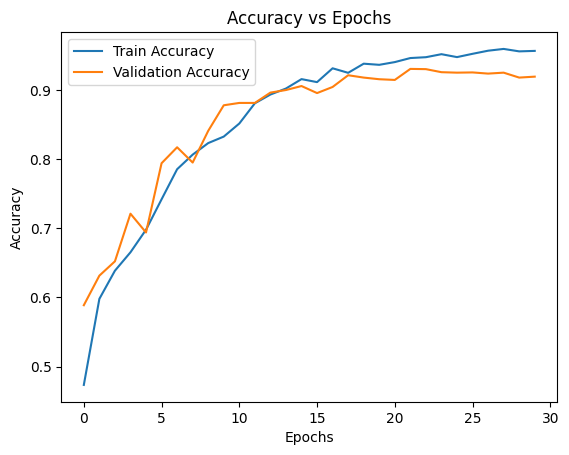

In [ ]:
#Accuracy Graph

import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

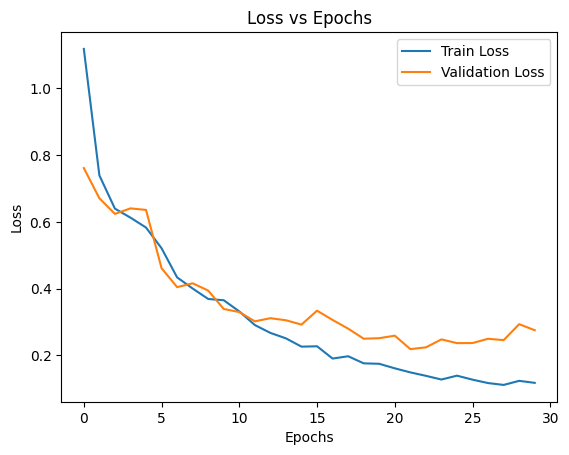

In [ ]:
#Loss Graph

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


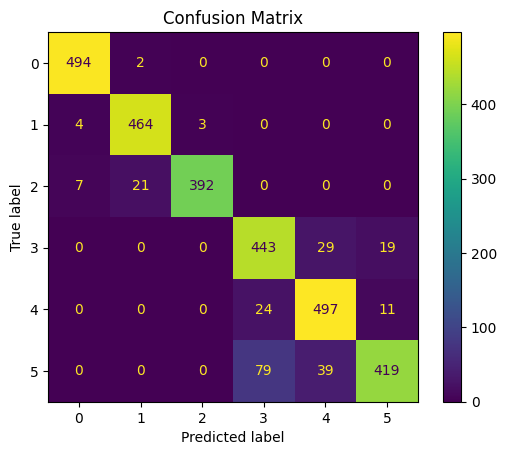

In [ ]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Label Mapping

labels = {
    0: "Walking",
    1: "Walking Upstairs",
    2: "Walking Downstairs",
    3: "Sitting",
    4: "Standing",
    5: "Laying"
}

print("Sample Prediction:", labels[y_pred_classes[0]])


Sample Prediction: Laying


In [ ]:
#Sensor Fusion

def sensor_fusion(data):
    accel_mag = np.sqrt(np.sum(data[:, :, :3]**2, axis=2))
    gyro_mag = np.sqrt(np.sum(data[:, :, 3:]**2, axis=2))
    return np.stack((accel_mag, gyro_mag), axis=2)

X_fused = sensor_fusion(X_train)
print("Fused Data Shape:", X_fused.shape)


In [ ]:
#Noise Smoothing

def smooth(signal, window=5):
    return np.convolve(signal, np.ones(window)/window, mode='valid')

plt.figure()
plt.plot(X_train[0][:, 0], label="Original")
plt.plot(smooth(X_train[0][:, 0]), label="Smoothed")
plt.title("Noise Reduction")
plt.legend()
plt.show()





In [ ]:
#Real-Time Prediction

def predict_realtime(sample):
    sample = np.expand_dims(sample, axis=0)
    pred = model.predict(sample)
    return labels[np.argmax(pred)]

print("Realtime Prediction:", predict_realtime(X_test[0]))


In [ ]:
#Transition Detection

def predict_realtime(sample):
    sample = np.expand_dims(sample, axis=0)
    pred = model.predict(sample)
    return labels[np.argmax(pred)]

def detect_transitions(preds):
    changes = []
    for i in range(1, len(preds)):
        if preds[i] != preds[i-1]:
            changes.append((i, preds[i-1], preds[i]))
    return changes

sequence_preds = [predict_realtime(X_test[i]) for i in range(20)]
print("Transitions:", detect_transitions(sequence_preds))